In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("loan_approval_data.csv")

In [5]:
print(df.head())
# print(df.describe())
# print(df.info())
# print(df.isnull().sum())

   Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status   Age  \
0           1.0           17795.0              1387.0          Salaried  51.0   
1           2.0            2860.0              2679.0          Salaried  46.0   
2           3.0            7390.0              2106.0          Salaried  25.0   
3           4.0           13964.0              8173.0          Salaried  40.0   
4           5.0           13284.0              4223.0     Self-employed  31.0   

  Marital_Status  Dependents  Credit_Score  Existing_Loans  DTI_Ratio  \
0        Married         0.0         637.0             4.0       0.53   
1        Married         3.0         621.0             2.0       0.30   
2         Single         2.0         674.0             4.0       0.20   
3        Married         2.0         579.0             3.0       0.31   
4         Single         2.0         721.0             1.0       0.29   

   Savings  Collateral_Value  Loan_Amount  Loan_Term Loan_Purpose  \
0  19

#           Handling missing values 

In [6]:
categorical_colm = df.select_dtypes(include=["object"]).columns
numerical_colm = df.select_dtypes(include=["number"]).columns

from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_colm] = num_imp.fit_transform(df[numerical_colm])

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_colm] = cat_imp.fit_transform(df[categorical_colm])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17044\6904576.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_colm = df.select_dtypes(include=["object"]).columns


In [7]:
print(df.isnull().sum())

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64


#           EDA

Text(0.5, 1.0, 'Is loan approved or not ?')

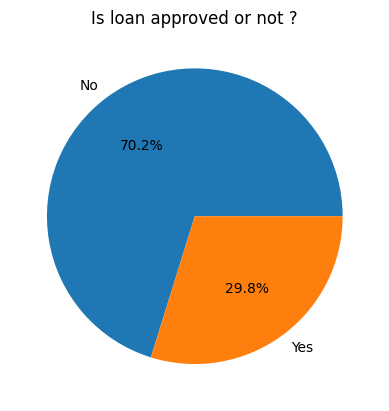

In [8]:
#pie chart
class_cnt = df["Loan_Approved"].value_counts()
plt.pie(class_cnt, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is loan approved or not ?")

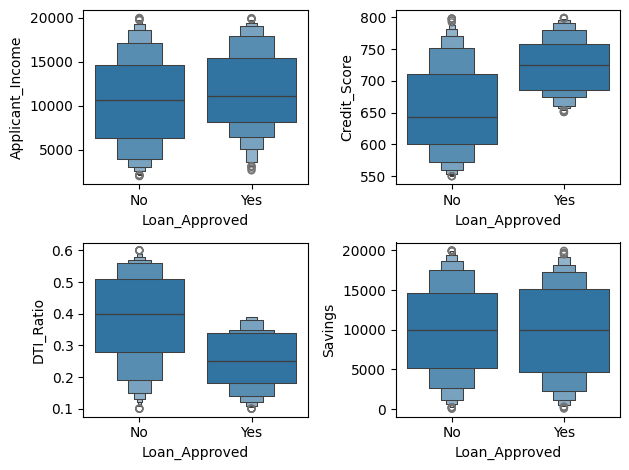

In [9]:
#boxen plot

fig, axes = plt.subplots(2, 2)
sns.boxenplot(ax = axes[0, 0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxenplot(ax = axes[0, 1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxenplot(ax = axes[1, 0], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxenplot(ax = axes[1, 1], data=df, x="Loan_Approved", y="Savings")
plt.tight_layout()

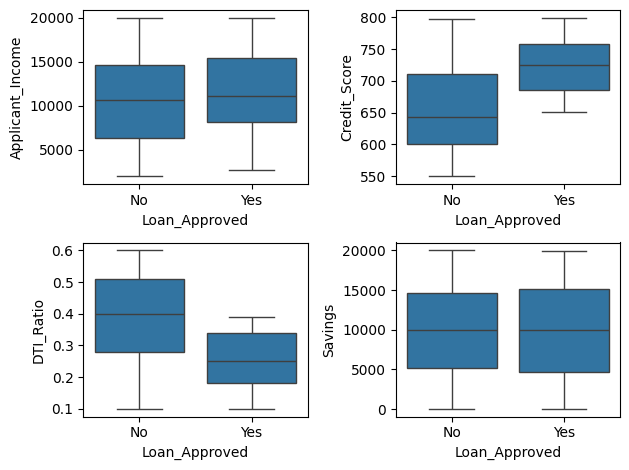

In [10]:
#boxen plot

fig, axes = plt.subplots(2, 2)
sns.boxplot(ax = axes[0, 0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax = axes[0, 1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax = axes[1, 0], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax = axes[1, 1], data=df, x="Loan_Approved", y="Savings")
plt.tight_layout()

In [11]:
# Remove Applicant_ID
df = df.drop("Applicant_ID", axis=1)

In [12]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Encoding

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [14]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [15]:
cols = ["Employer_Category", "Gender", "Property_Area", "Loan_Purpose", "Marital_Status", "Employment_Status"]

oh = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore") 
#sparse_output -> does not return sparse array and retrurn numpy array
#handle_unknowm -> it simply encodes all zeros, instead of crashing.

encoded = oh.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=oh.get_feature_names_out(cols), index=df.index)
#columns -> This makes the encoded features easy to interpret.
#index -> Without specifying the index, Pandas might create a new default index, making it harder to align rows correctly.

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [16]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

# Heatmap

<Axes: >

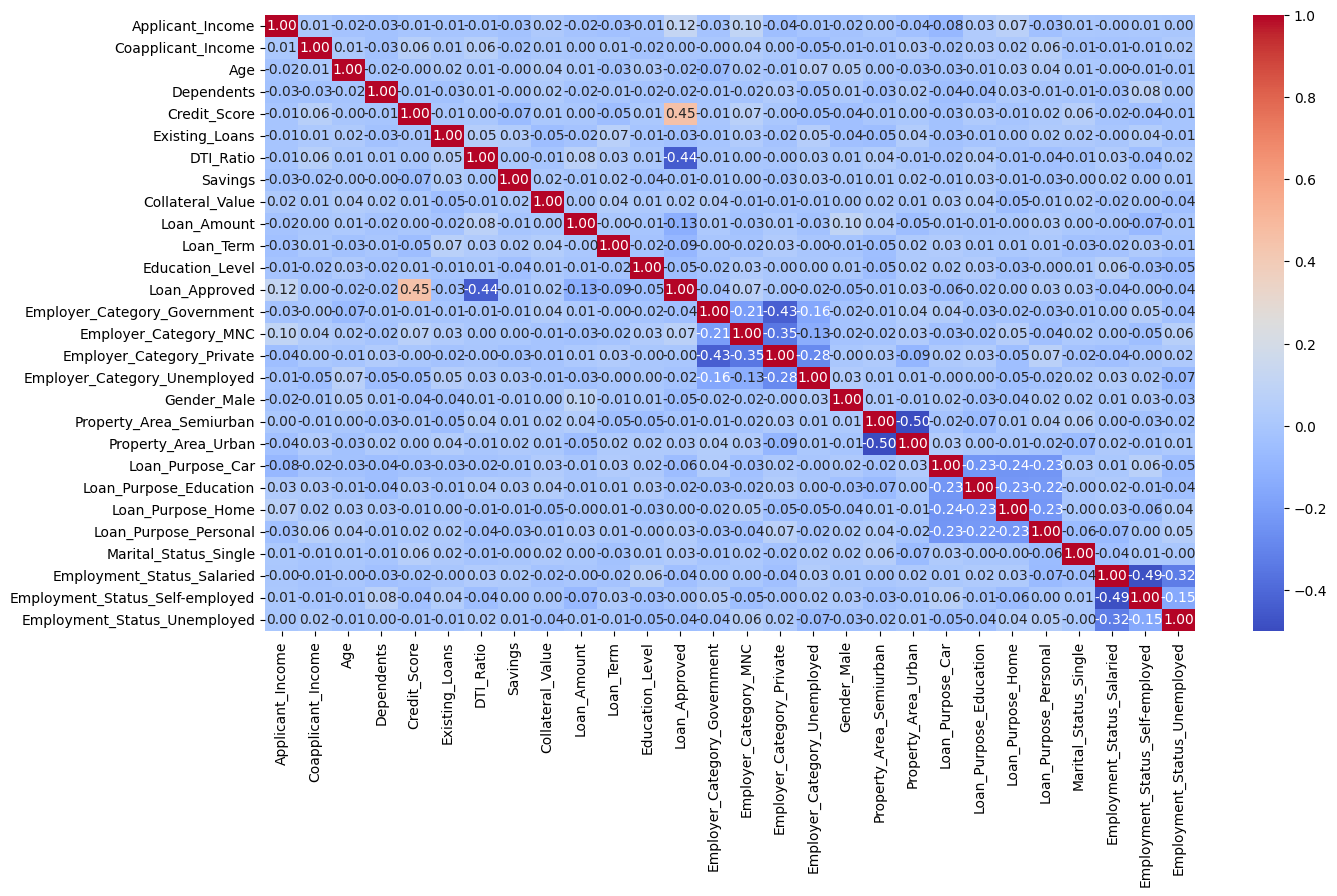

In [17]:
num_col = df.select_dtypes(include="number")
corr_mat = num_col.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [18]:
num_col.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# Train & Evaluate Models

In [22]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_sc, y_train)

y_pred = log_model.predict(X_test_sc)

# Evaluation
print("Logistic Regression")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

Logistic Regression
Precision :  0.7833333333333333
Recall :  0.7704918032786885
F1 score :  0.7768595041322314
Accuracy :  0.865
Confustion Matrix : 
 [[126  13]
 [ 14  47]]


In [23]:
#KNN

from sklearn.neighbors import KNeighborsClassifier
from kneed import KneeLocator

neigh = np.arange(1, 9)
precision = np.empty(len(neigh))


for i, k in enumerate(neigh):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)
    precision[i] = accuracy_score(y_test, y_pred)

kneedle = KneeLocator(neigh, precision, curve="concave", direction="increasing")
best_k = kneedle.knee

if best_k is None:
    best_k = neigh[np.argmax(precision)]

print("Best K =", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
y_pred = knn.predict(X_test_sc)

# Evaluation
print("KNN :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

Best K = 4
KNN :- 
Precision :  0.7241379310344828
Recall :  0.3442622950819672
F1 score :  0.4666666666666667
Accuracy :  0.76
Confustion Matrix : 
 [[131   8]
 [ 40  21]]


In [24]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_sc, y_train)

y_pred = nb_model.predict(X_test_sc)

# Evaluation
print("Naive Bayes :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

Naive Bayes :- 
Precision :  0.8035714285714286
Recall :  0.7377049180327869
F1 score :  0.7692307692307693
Accuracy :  0.865
Confustion Matrix : 
 [[128  11]
 [ 16  45]]


## Best Model on the basis of Precision till now => Naive Bayes

# Feature Engineering

In [25]:
# Add or Tranform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 29 to 102
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 800 non-null    float64
 1   Coapplicant_Income               800 non-null    float64
 2   Age                              800 non-null    float64
 3   Dependents                       800 non-null    float64
 4   Existing_Loans                   800 non-null    float64
 5   Savings                          800 non-null    float64
 6   Collateral_Value                 800 non-null    float64
 7   Loan_Amount                      800 non-null    float64
 8   Loan_Term                        800 non-null    float64
 9   Education_Level                  800 non-null    int64  
 10  Employer_Category_Government     800 non-null    float64
 11  Employer_Category_MNC            800 non-null    float64
 12  Employer_Category_Private        800 

In [27]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.7903225806451613
Recall:  0.8032786885245902
F1 score:  0.7967479674796748
Accuracy:  0.875
CM:  [[126  13]
 [ 12  49]]


In [28]:
#KNN

from sklearn.neighbors import KNeighborsClassifier
from kneed import KneeLocator

neigh = np.arange(1, 9)
precision = np.empty(len(neigh))


for i, k in enumerate(neigh):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    precision[i] = accuracy_score(y_test, y_pred)

kneedle = KneeLocator(neigh, precision, curve="concave", direction="increasing")
best_k = kneedle.knee

if best_k is None:
    best_k = neigh[np.argmax(precision)]

print("Best K =", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Evaluation
print("KNN :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

Best K = 4
KNN :- 
Precision :  0.7142857142857143
Recall :  0.32786885245901637
F1 score :  0.449438202247191
Accuracy :  0.755
Confustion Matrix : 
 [[131   8]
 [ 41  20]]


In [29]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.7833333333333333
Recall:  0.7704918032786885
F1 score:  0.7768595041322314
Accuracy:  0.865
CM:  [[126  13]
 [ 14  47]]


In [34]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluation
print("Decision Tree :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

Decision Tree :- 
Precision :  0.8166666666666667
Recall :  0.8032786885245902
F1 score :  0.8099173553719008
Accuracy :  0.885
Confustion Matrix : 
 [[128  11]
 [ 12  49]]


In [40]:
# pre pruning

max_depth = np.arange(2, 11)
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth= depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    print(f"for depth = {depth} , accuracy : {acc}")

min_test_split = np.arange(19, 24)
for split in min_test_split:
    model = DecisionTreeClassifier(max_depth=5, min_samples_split=split, random_state=42)
    model.fit(X_train_sc, y_train)
    acc = model.score(X_test_scaled, y_test)
    print(f"for sample split = {split} , accuracy : {acc}")


model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=20)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluation
print("\n\nDecision Tree (pre pruning) :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

for depth = 2 , accuracy : 0.885
for depth = 3 , accuracy : 0.89
for depth = 4 , accuracy : 0.91
for depth = 5 , accuracy : 0.915
for depth = 6 , accuracy : 0.91
for depth = 7 , accuracy : 0.9
for depth = 8 , accuracy : 0.91
for depth = 9 , accuracy : 0.91
for depth = 10 , accuracy : 0.9
for sample split = 19 , accuracy : 0.51
for sample split = 20 , accuracy : 0.51
for sample split = 21 , accuracy : 0.51
for sample split = 22 , accuracy : 0.495
for sample split = 23 , accuracy : 0.495


Decision Tree (pre pruning) :- 
Precision :  0.8235294117647058
Recall :  0.9180327868852459
F1 score :  0.8682170542635659
Accuracy :  0.915
Confustion Matrix : 
 [[127  12]
 [  5  56]]


In [45]:
# post pruning

full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train_scaled, y_train)

path = full_tree.cost_complexity_pruning_path(X_train_sc, y_train)
# ccp -> It returns the values of α (alpha) that can be used for pruning.

ccp_alphas = path.ccp_alphas
#Each alpha represents one level of pruning.

tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train_sc, y_train)
    tree.append((model, alpha))

best_acc = 0
best_alpha = 0
for model, alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc=curr_acc
        best_alpha = alpha

model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha, max_depth=5)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluation
print("Decision Tree (post pruning) :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

Decision Tree (post pruning) :- 
Precision :  0.8235294117647058
Recall :  0.9180327868852459
F1 score :  0.8682170542635659
Accuracy :  0.915
Confustion Matrix : 
 [[127  12]
 [  5  56]]


d:\VScode\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
d:\VScode\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
d:\VScode\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
d:\VScode\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
d:\VScode\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
d:\VScode\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but

In [46]:
# combining (pre and post):-

model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=20, ccp_alpha=best_alpha)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluation
print("Decision Tree (pre + post pruning) :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

Decision Tree (pre + post pruning) :- 
Precision :  0.8235294117647058
Recall :  0.9180327868852459
F1 score :  0.8682170542635659
Accuracy :  0.915
Confustion Matrix : 
 [[127  12]
 [  5  56]]


In [ ]:
# SVM

from sklearn.svm import SVC

model = SVC()       #defualt -> rbf
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluation
print("SVM :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

SVM :- 
Precision :  0.7735849056603774
Recall :  0.6721311475409836
F1 score :  0.7192982456140351
Accuracy :  0.84
Confustion Matrix : 
 [[127  12]
 [ 20  41]]


In [53]:
# Linear
model = SVC(kernel="linear")
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Linear Presision : ", precision_score(y_test, y_pred))

#polynomial
model = SVC(kernel="poly")
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("polynomial Presision : ", precision_score(y_test, y_pred))

#sigmoid
model = SVC(kernel="sigmoid")
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Sigmoid Presision : ", precision_score(y_test, y_pred))

Linear Presision :  0.8095238095238095
polynomial Presision :  0.8484848484848485
Sigmoid Presision :  0.8032786885245902


In [54]:
model = SVC(kernel="poly")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluation
print("SVM :- ")
print("Precision : ", precision_score(y_test, y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("Accuracy : ", accuracy_score(y_test, y_pred))
print("Confustion Matrix : \n", confusion_matrix(y_test, y_pred))

SVM :- 
Precision :  0.8484848484848485
Recall :  0.45901639344262296
F1 score :  0.5957446808510638
Accuracy :  0.81
Confustion Matrix : 
 [[134   5]
 [ 33  28]]


# Ensemble Learning